<a href="https://colab.research.google.com/github/VivekAChawla/camm_hackathon/blob/k4my4r/2025_XRD_simulator_Vivek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XRD spectra simulation

Author: Boris Slautin

powered by [pymatgen](https://pymatgen.org/)




In [ ]:
!pip install pymatgen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.1/753.1 kB 38.8 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=43549 sha256=97a04739d99c638d67ff4488e00dafb8fcb5e77c4116442f9108ec2a8ba4887e
  Stored in directory: /root/.cache/pip/wheels/1f/7d/e9/1ff2509f13767a55df1279744adfb757f4ab94b2cbe761f56a
Successfully built bibtexparser


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 1 Phase diagramm

=====================================

###Pb(Zr₁₋ₓTiₓ)O₃ (PZT) PHASE DIAGRAM

=====================================

This module defines the crystallographic phase of PZT as a function
of titanium composition `x` and temperature `T`. It provides an
approximate, continuous model suitable for phase-field simulations,
structure factor generation, or diffraction pattern prediction.

The main function `pzt_phase(x, T)` returns a dictionary describing:

* `phase`: qualitative name of the stable phase (cubic, rhombohedral,
  tetragonal, monoclinic, or mixed R+T)
* `symmetry`: associated space group or point group
* `parameters`: lattice constants {a,b,c,alpha,beta,gamma}, including
  optional phase fractions in the coexistence region

The function internally determines:

1. The Curie temperature `Tc(x)` separating ferroelectric and
   paraelectric regions, estimated by a polynomial fit (`Tc_fit`).
2. The morphotropic phase boundary (MPB) range between 0.45 < x < 0.52,
   which controls the transition between rhombohedral and tetragonal
   symmetries, with a monoclinic bridging phase near x ≈ 0.48.
3. Temperature- and composition-dependent lattice parameters derived
from simplified, physically consistent empirical relations.
Vegard-type linear interpolation with respect to composition is
used in the cubic and tetragonal regions to represent solid-solution
behavior, combined with first-order thermal expansion (~1×10⁻⁵/°C).

Behavior by region:

* T > Tc(x): cubic paraelectric phase (Pm-3m)
* x < 0.45: rhombohedral (R3m)
* x > 0.52: tetragonal (P4mm)
* 0.45 ≤ x ≤ 0.52 and low T: monoclinic (Cm)
* 0.45 ≤ x ≤ 0.52 and high T: mixed R+T coexistence

Supporting helper functions:

* `Tc_fit(x)`: Curie temperature (°C)
* `T_monoclinic_upper(x)`: temperature limit of monoclinic phase
* `rhombohedral_params(x, T)`: returns a, α
* `tetragonal_params(x, T)`: returns a, c
* `monoclinic_params(x, T)`: returns a, b, c, β
* `a_cubic_fit(x, T)`: returns cubic lattice constant

All geometric parameters include first-order thermal expansion (~1×10⁻⁵/°C).
These parameterizations reproduce the main experimental features of the
PZT phase diagram near room temperature and the morphotropic boundary,
providing a consistent and computationally lightweight structural model.



> Note: This is a simplified phase diagram. All parameters were derived from literature sources identified by the ChatGPT model. Some discrepancies with experimental data may remain.



In [ ]:
# ================================================================
# MAIN PHASE FUNCTION
# ================================================================

def pzt_phase(x: float, T: float):
    """
    Returns a dictionary formatted for structure / XRD simulation.

    Output keys:
      'phase'      – phase name
      'symmetry'   – space group or crystal class
      'parameters' – dict with {a,b,c,alpha,beta,gamma}
    """

    Tc = Tc_fit(x)
    if T > Tc:
        # Cubic paraelectric phase
        a = a_cubic_fit(x, T)
        return {
            "phase": "cubic",
            "symmetry": "Pm-3m",
            "parameters": {"a": a, "b": a, "c": a,
                           "alpha": 90, "beta": 90, "gamma": 90}
        }

    # Phase-field below Tc
    x_mpb_low, x_mpb_high = 0.45, 0.52

    if x < x_mpb_low:
        # Rhombohedral
        p = rhombohedral_params(x, T)
        return {
            "phase": "rhombohedral",
            "symmetry": "R3m",
            "parameters": {"a": p["a"], "b": p["a"], "c": p["a"],
                           "alpha": p["alpha"], "beta": p["alpha"], "gamma": p["alpha"]}
        }

    elif x > x_mpb_high:
        # Tetragonal
        p = tetragonal_params(x, T)
        return {
            "phase": "tetragonal",
            "symmetry": "P4mm",
            "parameters": {"a": p["a"], "b": p["a"], "c": p["c"],
                           "alpha": 90, "beta": 90, "gamma": 90}
        }

    else:
        # MPB region
        if T < T_monoclinic_upper(x):
            p = monoclinic_params(x, T)
            return {
                "phase": "monoclinic",
                "symmetry": "Cm",
                "parameters": {"a": p["a"], "b": p["b"], "c": p["c"],
                               "alpha": 90, "beta": p["beta"], "gamma": 90}
            }
        else:
            # Mixed R+T coexistence
            w_t = (x - x_mpb_low) / (x_mpb_high - x_mpb_low)
            w_r = 1 - w_t
            p_r = rhombohedral_params(x_mpb_low, T)
            p_t = tetragonal_params(x_mpb_high, T)
            return {
                "phase": "mixed R+T",
                "symmetry": "mixed",
                "parameters": {
                    "a": (p_r["a"], p_t["a"]),
                    "b": (p_r["a"], p_t["a"]),
                    "c": (p_r["a"], p_t["c"]),
                    "alpha": (p_r["alpha"], 90),
                    "beta": (p_r["alpha"], 90),
                    "gamma": (p_r["alpha"], 90),
                    "phase_fraction": {"rhombohedral": w_r, "tetragonal": w_t}
                }
            }


# ================================================================
# PARAMETER MODELS (simplified but physically consistent)
# ================================================================

def Tc_fit(x):
    """Approximate Curie temperature in °C for Pb(Zr₁₋ₓTiₓ)O₃."""
    return 300 + 200*x - 50*x**2

def T_monoclinic_upper(x):
    """Upper stability of monoclinic (MPB) phase."""
    x0, width, Tmax = 0.48, 0.04, 200
    if abs(x - x0) > width:
        return 0
    return Tmax * (1 - abs(x - x0) / width)


def rhombohedral_params(x, T):
    """
    Approximate lattice parameters for the rhombohedral region of PZT.
    Returns dict with: a, alpha (deg).
    """
    # base reference at x=0.45 (near MPB) and T=25 °C
    a_ref = 4.06   # approx pseudocubic equivalent
    alpha_ref = 89.8

    # at x=0 (Zr-rich end) assume a0 ~4.11 Å, alpha0 ~89.6°
    a0 = 4.11
    alpha0 = 89.6

    frac = x / 0.45
    a = a0 + (a_ref - a0) * frac
    alpha = alpha0 + (alpha_ref - alpha0) * frac

    # thermal expansion (≈1e-5 /°C)
    a *= (1 + 1e-5 * (T - 25))
    return {"a": a, "alpha": alpha}

def tetragonal_params(x, T):
    # assume x in [0.52, 1.0]
    a_t0 = 4.044
    c_t0 = 4.138
    # maybe for x=1 (PbTiO3) a≈3.90, c≈4.15
    a_t1 = 3.90
    c_t1 = 4.15

    frac = (x - 0.52) / (1.0 - 0.52)
    a = a_t0 + (a_t1 - a_t0)*frac
    c = c_t0 + (c_t1 - c_t0)*frac

    alpha_th = 1e-5
    a *= (1 + alpha_th*(T - 25))
    c *= (1 + alpha_th*(T - 25))
    return {"a": a, "b": a, "c": c}

def monoclinic_params(x, T):
    """Monoclinic (MPB) PZT parameters."""
    T0, x0 = 25, 0.48
    a = 5.72 + 0.05*(x - x0)
    b = 5.70 - 0.05*(x - x0)
    c = 4.14
    beta = 90.5 + 0.2*(x - x0)
    a *= 1 + 1e-5 * (T - T0)
    b *= 1 + 1e-5 * (T - T0)
    c *= 1 + 1e-5 * (T - T0)
    return {"a": a, "b": b, "c": c, "beta": beta}

def a_cubic_fit(x, T):
    """Cubic paraelectric lattice parameter (Vegard + expansion)."""
    a = 4.14 - 0.17 * x
    return a * (1 + 1.1e-5 * (T - 25))


In [ ]:
# Encode phase regions numerically over (T, x) grid using pzt_phase().
# Each unique phase name is assigned an integer key for visualization.

def ensure_key(d, key):
    if key not in d:
        d[key] = len(d)
    return d

tt = np.linspace(0, 500, 1000)
xx = np.linspace(0, 1, 1000)



TT, XX = np.meshgrid(tt, xx, indexing="ij")
phase = np.zeros_like(TT)
a = np.zeros_like(TT)

enc_phases = {}
for i in range(TT.shape[0]):
  for j in range(TT.shape[1]):
    res_dict = pzt_phase(XX[i,j], TT[i,j])
    ph = res_dict['phase']
    enc_phases = ensure_key(enc_phases, ph)

    phase[i,j] = enc_phases[ph]

    aa = res_dict['parameters']['a']

    if isinstance(aa, tuple):
      w_t = list(res_dict['parameters']['phase_fraction'].values())

      aa =(aa[0]*w_t[0] + aa[1]*w_t[1])

    a[i,j] = aa

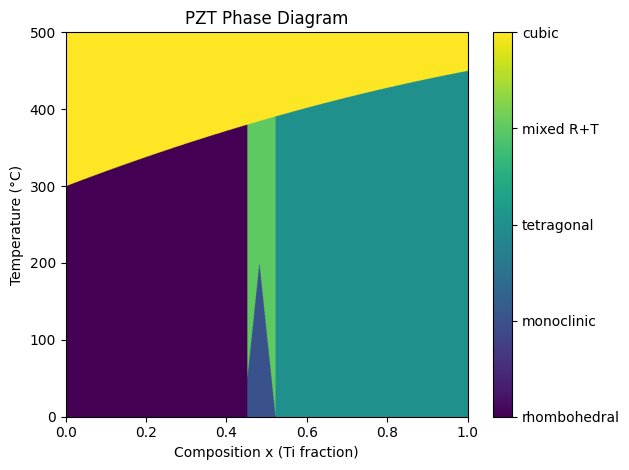

In [ ]:
im = plt.imshow(phase,
           origin='lower',
           extent=(xx.min(), xx.max(), tt.min(), tt.max()),
           aspect='auto'
           )
# create colorbar
cbar = plt.colorbar(im)

# set tick positions and labels
tick_positions = list(enc_phases.values())
tick_labels = list(enc_phases.keys())

cbar.set_ticks(tick_positions)
cbar.set_ticklabels(tick_labels)

# optionally rotate labels for readability
plt.setp(cbar.ax.get_yticklabels(), rotation=0, ha='left')

plt.xlabel("Composition x (Ti fraction)")
plt.ylabel("Temperature (°C)")
plt.title("PZT Phase Diagram")
plt.tight_layout()
plt.show()

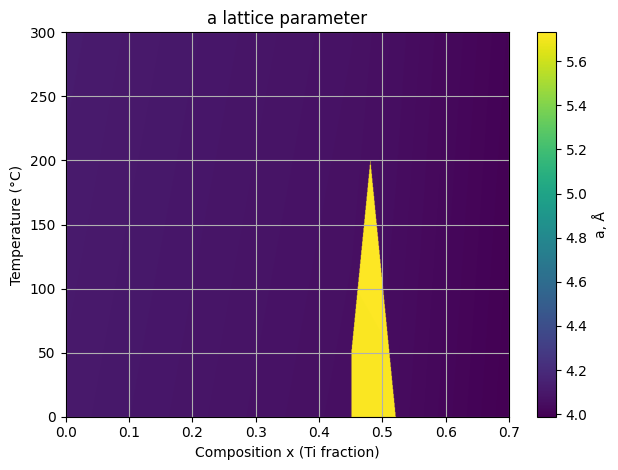

In [ ]:
#define region of interest in the Phase Diagramm
tt = np.linspace(0, 300, 1000)
xx = np.linspace(0, .7, 1000)


TT, XX = np.meshgrid(tt, xx, indexing="ij")
a = np.zeros_like(TT)

enc_phases = {}
for i in range(TT.shape[0]):
  for j in range(TT.shape[1]):
    res_dict = pzt_phase(XX[i,j], TT[i,j])
    aa = res_dict['parameters']['a']

    if isinstance(aa, tuple):
      w_t = list(res_dict['parameters']['phase_fraction'].values())
      aa =(aa[0]*w_t[0] + aa[1]*w_t[1])

    a[i,j] = aa

im = plt.imshow(a,
           origin='lower',
           extent=(xx.min(), xx.max(), tt.min(), tt.max()),
           aspect='auto',)
# create colorbar
cbar = plt.colorbar(im, label="a, Å")

plt.xlabel("Composition x (Ti fraction)")
plt.ylabel("Temperature (°C)")
plt.title("a lattice parameter")
plt.grid()
plt.tight_layout()


# 2. XRD Simulator

=====================================================

### CRYSTALBUILDER: UNIVERSAL STRUCTURE AND XRD GENERATOR

=====================================================

This class constructs crystallographic models and corresponding X-ray
diffraction (XRD) patterns from provided symmetry and lattice parameters.
It supports both single-phase and mixed-phase (e.g., MPB) systems using
pymatgen’s `Lattice` and `Structure` objects together with the
`XRDCalculator` module.

Purpose:
The class is designed to bridge phenomenological phase-field or
thermodynamic models (such as `pzt_phase`) with crystallographic
and diffraction-based observables. It enables rapid visualization
of composition–temperature-dependent structural evolution.

Key features:]

• Supports multiple crystal symmetries:
cubic, tetragonal, rhombohedral, monoclinic, orthorhombic,
hexagonal, and triclinic.

• Accepts either single-phase parameters or mixed-phase descriptions
with phase fractions (e.g., "rhombohedral" + "tetragonal").

• Generates pymatgen `Structure` objects and simulates XRD patterns
for each phase, including Gaussian broadening to approximate
instrumental effects.

Internal workflow:

1. `__init__` initializes with symmetry, parameters, and optional
   species/atomic coordinates. If `phase_fraction` is present in
   `parameters`, it automatically constructs multiple structures
   with appropriate weighting.
2. `_build_lattice()` creates a single `Lattice` instance based on
   crystal symmetry and metric tensor parameters.
3. `_build_mixed_lattices()` handles coexistence regions by building
   several lattices, each associated with its phase fraction and
   symmetry type. Parameters can be tuples or scalars.
4. `broaden_pattern()` converts discrete ("stick") XRD peaks into a
   continuous profile using Gaussian broadening with specified FWHM.
5. `get_xrd_pattern()` calculates the combined diffraction intensity
   over a 2θ grid, summing phase contributions according to their
   fractions and normalizing the total intensity.
6. `summary()` provides a compact report of all generated structures
   and associated parameters.

Typical usage:

builder = CrystalBuilder(symmetry, params)

pattern = builder.get_xrd_pattern()

plt.plot(pattern["2theta"], pattern["intensity"])

This implementation provides a compact yet extensible framework for
constructing structure-based diffraction models directly from
composition–temperature–phase diagrams, supporting both fundamental
analysis and AI-driven materials discovery workflows.


In [ ]:
import numpy as np
from pymatgen.core import Lattice, Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

class CrystalBuilder:
    """
    Universal structure + XRD pattern generator supporting mixed phases (MPB).
    """

    def __init__(self, symmetry, parameters, species=None, coords=None):
        self.symmetry = symmetry.lower()
        self.parameters = parameters
        self.species = species or ["A", "B", "O", "O", "O"]
        self.coords = coords or [
            [0, 0, 0], [0.5, 0.5, 0.5],
            [0.5, 0.5, 0.0], [0.5, 0.0, 0.5], [0.0, 0.5, 0.5]
        ]

        # If mixed phases (e.g., MPB), store multiple structures
        if "phase_fraction" in parameters:
            self.structures = self._build_mixed_lattices()
        else:
            self.lattice = self._build_lattice()
            self.structure = Structure(self.lattice, self.species, self.coords)
            self.structures = {self.symmetry: (self.structure, 1.0)}

    # -------------------------------------------------------------
    def _build_lattice(self):
        """Build pymatgen Lattice from symmetry and parameters."""
        p = self.parameters
        sym = self.symmetry
        sg_map = {
            "p4mm": "tetragonal",
            "r3m": "rhombohedral",
            "r3c": "rhombohedral",
            "cm": "monoclinic",
            "pm-3m": "cubic"
        }
        sym = sg_map.get(sym, sym)

        if sym == "cubic":
            return Lattice.cubic(p["a"])
        elif sym == "tetragonal":
            return Lattice.tetragonal(p["a"], p["c"])
        elif sym == "rhombohedral":
            return Lattice.rhombohedral(p["a"], p.get("alpha", 89.9))
        elif sym == "monoclinic":
            return Lattice.monoclinic(p["a"], p["b"], p["c"], p.get("beta", 90.0))
        else:
            raise ValueError(f"Unknown symmetry type: {sym}")

    # -------------------------------------------------------------
    def _build_mixed_lattices(self):
        """
        Handle mixed-phase systems (e.g., MPB, solid solutions).
        Automatically detects available symmetries and constructs appropriate lattices.
        """
        p = self.parameters
        fractions = p["phase_fraction"]
        lattices = {}

        # Helper to safely extract tuple or scalar parameter
        def get_param(name, idx, default=None):
            val = p.get(name, default)
            if isinstance(val, (list, tuple)):
                return val[idx]
            return val

        # Map of symmetry → corresponding pymatgen lattice constructor
        lattice_builders = {
            "cubic": lambda i: Lattice.cubic(get_param("a", i)),
            "tetragonal": lambda i: Lattice.tetragonal(get_param("a", i), get_param("c", i)),
            "orthorhombic": lambda i: Lattice.orthorhombic(
                get_param("a", i), get_param("b", i), get_param("c", i)
            ),
            "hexagonal": lambda i: Lattice.hexagonal(get_param("a", i), get_param("c", i)),
            "rhombohedral": lambda i: Lattice.rhombohedral(
                get_param("a", i), get_param("alpha", i, 89.9)
            ),
            "monoclinic": lambda i: Lattice.monoclinic(
                get_param("a", i), get_param("b", i), get_param("c", i), get_param("beta", i, 90.0)
            ),
            "triclinic": lambda i: Lattice.from_parameters(
                get_param("a", i), get_param("b", i), get_param("c", i),
                get_param("alpha", i, 90), get_param("beta", i, 90), get_param("gamma", i, 90)
            ),
        }

        # Iterate over each phase (e.g. "rhombohedral", "tetragonal", "cubic" ...)
        for i, (phase_name, frac) in enumerate(fractions.items()):
            phase_key = phase_name.lower()
            if phase_key not in lattice_builders:
                raise ValueError(f"Unsupported symmetry: {phase_key}")

            lattice = lattice_builders[phase_key](i)
            structure = Structure(lattice, self.species, self.coords)
            lattices[phase_key] = (structure, frac)

        return lattices

    # -------------------------------------------------------------
    def broaden_pattern(self, two_theta, intensities, two_theta_range=(10, 80), step=0.01, fwhm=0.05):
        """Return a smooth diffraction pattern from stick data."""
        grid = np.arange(two_theta_range[0], two_theta_range[1], step)
        sigma = fwhm / (2*np.sqrt(2*np.log(2)))
        I = np.zeros_like(grid)
        for t, h in zip(two_theta, intensities):
            I += h * np.exp(-0.5 * ((grid - t)/sigma)**2)
        return grid, I / I.max()

    # -------------------------------------------------------------
    def get_xrd_pattern(self, wavelength="CuKa", two_theta_range=(10, 80), step=0.01, fwhm=0.1):
        """Compute XRD pattern (supports single or mixed phase)."""
        calc = XRDCalculator(wavelength=wavelength)
        tt = np.arange(two_theta_range[0], two_theta_range[1], step)
        I_total = np.zeros_like(tt)
        patterns = []
        for name, (struct, weight) in self.structures.items():
            patt = calc.get_pattern(struct)
            patterns.append(patt)
            tt_b, I_b = self.broaden_pattern(np.array(patt.x), np.array(patt.y),
                                             two_theta_range, step, fwhm)
            I_total += weight * np.interp(tt, tt_b, I_b)

        return {"2theta": tt, "intensity": I_total / I_total.max(), "components": self.structures, 'patterns': patterns}

    # -------------------------------------------------------------
    def summary(self):
        """Return parameters and structures."""
        return {"symmetry": self.symmetry, "parameters": self.parameters, "structures": self.structures}


In [ ]:
#estimate XRD spectra
x = .2
T = 400 #Celsius

phase_data = pzt_phase(x=x, T=T)
builder = CrystalBuilder(
    symmetry=phase_data["symmetry"],
    parameters=phase_data["parameters"],
    species=["Pb", {"Zr": 1-x, "Ti":x}, "O", "O", "O"]
)
pattern = builder.get_xrd_pattern( two_theta_range=(20, 60),)

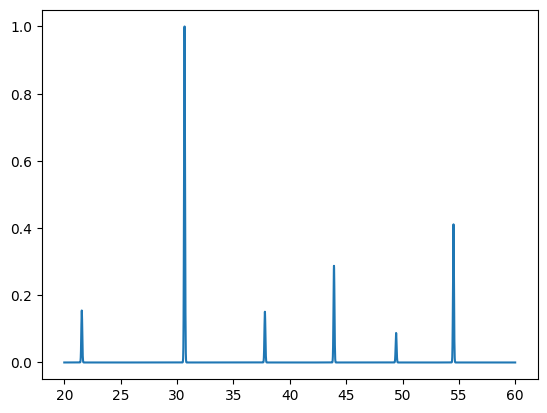

In [ ]:
#Emulated experimental diffraction spectrum with Gaussian peak broadening to mimic instrumental effects.
plt.plot(pattern['2theta'], pattern['intensity'])

In [ ]:
print('Peak position:')
print(pattern['patterns'][0].x)

print('Intensities:')
print(pattern['patterns'][0].y)

Peak position:
[21.55355857 30.66666847 37.79357869 43.92088887 49.43028248 54.51798379
 63.85805188 68.24298871 72.49760537 76.65463338 80.74116311 84.78062408
 88.79418303]
Intensities:
[ 15.47407559 100.          15.10501294  28.68038234   8.75393185
  41.02580669  18.04317081   4.68742064  17.97862457   5.46803663
   6.14172669   2.34131429  22.57890424]


# Using it to check GEMINI performance

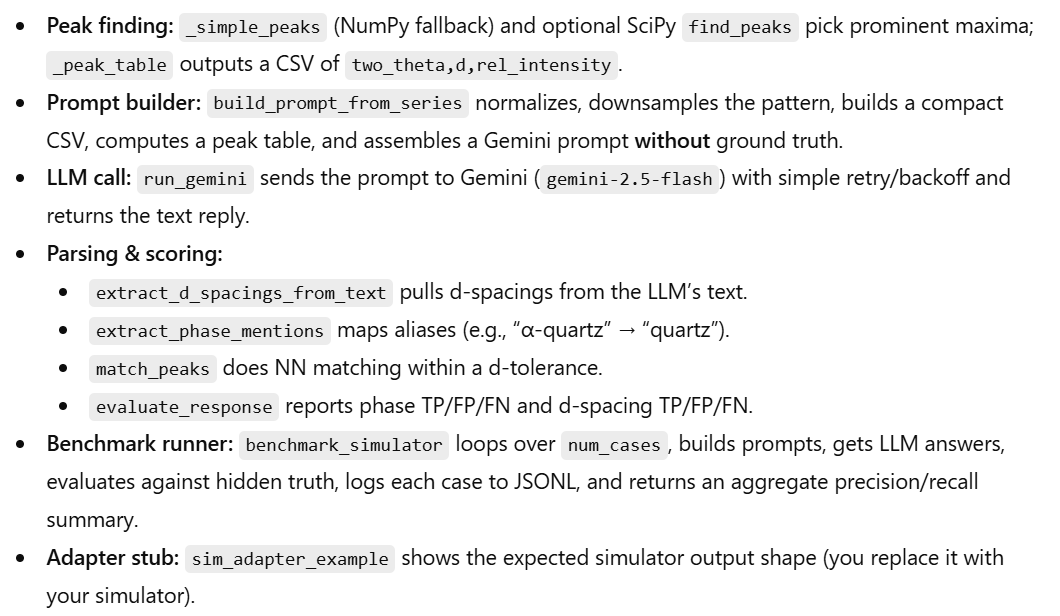

In [ ]:
import google.generativeai as genai
from PIL import Image
genai.configure(api_key="YOUR KEY HERE")
import time
from matplotlib.colors import LogNorm

In [ ]:
# =========================
# Gemini XRD Benchmark (no ground-truth leakage)
# =========================
import os, re, json, math, random, time
import numpy as np
from math import sin, radians
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Tuple

# ---- optional: gemini client (assumes you've configured env + genai earlier)
try:
    import google.generativeai as genai
    _HAVE_GEMINI = True
except Exception:
    _HAVE_GEMINI = False

# ---------- peak finding (same spirit as your prior) ----------
try:
    from scipy.signal import find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

def _simple_peaks(y, min_prom=0.02):
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    lm = (y[1:-1] > y[:-2]) & (y[1:-1] > y[2:])
    idx = np.nonzero(lm)[0] + 1
    idx = idx[y[idx] >= min_prom]
    order = np.argsort(y[idx])[::-1]
    return idx[order]

def _peak_table(two_theta, intensity, wavelength_A=None, max_peaks=25):
    """
    Returns CSV (header: two_theta_deg,d_A,rel_intensity)
    rel_intensity computed from normalized y.
    """
    y = (intensity - intensity.min())
    y = y / (y.max() + 1e-12)

    if _HAVE_SCIPY:
        peaks, props = find_peaks(y, prominence=0.02, width=1)
        if peaks.size:
            order = np.argsort(props["prominences"])[::-1]
            peaks = peaks[order]
    else:
        peaks = _simple_peaks(intensity, min_prom=0.02)

    peaks = np.sort(peaks[:max_peaks])

    lines = ["two_theta_deg,d_A,rel_intensity"]
    for p in peaks:
        tt = float(two_theta[p])
        rel = float(y[p])
        if wavelength_A is not None and tt > 0:
            theta = radians(tt / 2.0)
            dA = float(wavelength_A / (2.0 * sin(theta))) if theta != 0 else np.inf
        else:
            dA = np.nan
        lines.append(f"{tt:.4f},{dA:.5f},{rel:.4f}")
    return "\n".join(lines)

# ---------- prompt builder ----------
def build_prompt_from_series(
    two_theta: np.ndarray,
    intensity: np.ndarray,
    meta: Dict[str, Any],
    question: str,
    *,
    max_points: int = 1200,
    normalize: bool = True,
    wavelength_override: str | float | None = "CuKa",
    instrument_profile: str = "Aeris-fds-Pixcel1D-Medipix3",
) -> Tuple[str, str, str]:
    """
    Returns (prompt, peaks_csv, csv_snippet) – for logging.
    No ground truth included.
    """
    # wavelength
    wl_A = None
    wl_label = str(meta.get("wavelength"))
    if isinstance(wavelength_override, (int, float)):
        wl_A = float(wavelength_override)
        wl_label = f"{wl_A:.5f} Å (override)"
    elif isinstance(wavelength_override, str) and wavelength_override:
        key = wavelength_override.strip().lower()
        if key in {"cuka", "cu", "cu kα", "cu kalpha"}:
            wl_A = 1.5406
            wl_label = "Cu Kα (1.5406 Å, override)"
        elif key in {"coka", "co", "co kα", "co kalpha"}:
            wl_A = 1.78897
            wl_label = "Co Kα (1.78897 Å, override)"

    # normalize
    if normalize:
        rng = (intensity.max() - intensity.min()) or 1.0
        yy = (intensity - intensity.min()) / rng
        header = "2theta_deg,intensity_norm"
    else:
        yy = intensity
        header = "2theta_deg,intensity"

    # downsample
    if len(yy) > max_points:
        idx = np.linspace(0, len(yy) - 1, max_points).astype(int)
        tt_ds = two_theta[idx]
        ii_ds = yy[idx]
    else:
        tt_ds, ii_ds = two_theta, yy

    series_lines = [header]
    series_lines += [f"{tt_ds[i]:.5f},{ii_ds[i]:.6g}" for i in range(len(ii_ds))]
    csv_snippet = "\n".join(series_lines)

    peaks_csv = _peak_table(two_theta, intensity if not normalize else yy, wavelength_A=wl_A, max_peaks=25)

    system_preamble = (
        "You are an expert in powder X-ray diffraction (XRD). "
        "Given the pattern below, answer the user's question. "
        "Use the peak table for reasoning (phases, key peaks, approximate d-spacings), "
        "and note caveats (background, Kα2, zero-shift, preferred orientation, size/strain). "
        "Be concise and structured."
    )

    meta_text = (
        f"Axis={meta.get('axis','2theta')} ({meta.get('axis_unit','deg')}), "
        f"Intensity unit={meta.get('intensity_unit','arb')}, "
        f"Wavelength={wl_label}, "
        f"Instrument profile={instrument_profile}, "
        f"Points={meta.get('n_points', len(two_theta))}, "
        f"Range={meta.get('two_theta_min', float(two_theta.min())):.3f}–{meta.get('two_theta_max', float(two_theta.max())):.3f} {meta.get('axis_unit','deg')}."
    )

    # IMPORTANT: no ground truth in prompt
    prompt = (
        f"{system_preamble}\n\n"
        f"User question:\n{question}\n\n"
        f"Pattern metadata:\n{meta_text}\n\n"
        f"Peak table (top peaks by prominence):\n{peaks_csv}\n\n"
        f"Downsampled pattern (CSV):\n{csv_snippet}\n"
    )
    return prompt, peaks_csv, csv_snippet

# ---------- Gemini call ----------
def run_gemini(prompt: str, model_name: str = "gemini-2.5-flash", retries: int = 2, backoff_s: float = 2.0) -> str:
    if not _HAVE_GEMINI:
        raise RuntimeError("google-generativeai not available. Please install and configure your API key.")
    model = genai.GenerativeModel(model_name)
    for attempt in range(retries + 1):
        try:
            resp = model.generate_content(prompt)
            return getattr(resp, "text", "").strip()
        except Exception as e:
            if attempt >= retries:
                raise
            time.sleep(backoff_s * (attempt + 1))
    return ""

# ---------- evaluation helpers ----------
@dataclass
class EvalConfig:
    # d-spacing matching tolerance (Å)
    d_tol_A: float = 0.02
    # how many truth peaks to evaluate against
    top_truth_peaks: int = 10
    # alias map for phase names
    alias_map: Dict[str, List[str]] = None

def _default_alias_map():
    return {
        "quartz": ["quartz", "α-quartz", "alpha quartz", "siO2", "sio2", "silica"],
        "corundum": ["corundum", "al2o3", "α-al2o3", "alumina"],
        "zincite": ["zincite", "zno"],
        "rutile": ["rutile", "tio2 rutile"],
        "anatase": ["anatase", "tio2 anatase"],
        "geO2-quartz": ["geO2-quartz", "α-geO2", "germania quartz", "geo2"],
        # extend per your simulator phase list...
    }

def extract_d_spacings_from_text(txt: str) -> List[float]:
    """
    Parse d-spacings like 3.343 Å, 3.343A, d=3.343, or just 3.343 (Å implied).
    """
    ds = []
    # capture numbers optionally prefixed by d= and optionally followed by Å/A/Ang
    for m in re.finditer(r"(?:d\s*=\s*)?([0-9]*\.[0-9]+|[0-9]+)(?:\s*(?:Å|A|Ang|Angstrom))?", txt, flags=re.I):
        try:
            ds.append(float(m.group(1)))
        except:
            pass
    # Filter to a reasonable XRD d-range (0.8–10 Å) to avoid catching 2θ or percentages
    ds = [d for d in ds if 0.8 <= d <= 10.0]
    # Deduplicate near-equals
    ds_sorted = []
    for d in sorted(ds):
        if not ds_sorted or abs(d - ds_sorted[-1]) > 1e-3:
            ds_sorted.append(d)
    return ds_sorted

def extract_phase_mentions(txt: str, truth_candidates: List[str], alias_map: Dict[str, List[str]]) -> List[str]:
    """
    Return canonical phases (subset of truth_candidates) that were mentioned in text (using alias map).
    """
    found = set()
    low = txt.lower()
    for canon in truth_candidates:
        aliases = set([canon.lower()]) | set(a.lower() for a in alias_map.get(canon, []))
        if any(a in low for a in aliases):
            found.add(canon)
    return sorted(found)

def match_peaks(llm_ds: List[float], truth_ds: List[float], d_tol_A: float) -> Tuple[int, int, int]:
    """
    Return (TP, FP, FN) by nearest-neighbor matching within tolerance.
    """
    truth = list(sorted(truth_ds))
    used = [False] * len(truth)
    TP = 0
    for d in sorted(llm_ds):
        best_i, best_delta = -1, 1e9
        for i, td in enumerate(truth):
            if used[i]:
                continue
            delta = abs(d - td)
            if delta < best_delta:
                best_delta, best_i = delta, i
        if best_i >= 0 and best_delta <= d_tol_A:
            used[best_i] = True
            TP += 1
    FP = max(0, len(llm_ds) - TP)
    FN = used.count(False)
    return TP, FP, FN

def evaluate_response(
    llm_text: str,
    truth_phases: List[str],
    truth_peaks_dA: List[float],
    cfg: EvalConfig,
) -> Dict[str, Any]:
    alias_map = cfg.alias_map or _default_alias_map()

    # phases
    phases_found = extract_phase_mentions(llm_text, truth_phases, alias_map)
    # scores
    set_true = set(truth_phases)
    set_pred = set(phases_found)
    tp_phase = len(set_true & set_pred)
    fp_phase = len(set_pred - set_true)
    fn_phase = len(set_true - set_pred)

    # peaks: compare against top-N truth d's
    truth_top = list(sorted(truth_peaks_dA))[: cfg.top_truth_peaks]
    llm_ds = extract_d_spacings_from_text(llm_text)
    TP, FP, FN = match_peaks(llm_ds, truth_top, cfg.d_tol_A)

    return {
        "phases_pred": sorted(list(set_pred)),
        "phases_true": sorted(list(set_true)),
        "phase_tp": tp_phase, "phase_fp": fp_phase, "phase_fn": fn_phase,
        "d_list_pred": llm_ds,
        "d_list_true_topN": truth_top,
        "d_tp": TP, "d_fp": FP, "d_fn": FN,
    }

# ---------- benchmark runner ----------
def benchmark_simulator(
    sim_fn,                 # callable: i -> dict(two_theta, intensity, meta, truth_phases, truth_dA_peaks)
    num_cases: int = 5,
    question: str = "Identify likely phases, list 3 characteristic peaks (d, Å) per phase, and note any artifacts (size/strain, zero-shift, preferred orientation).",
    model_name: str = "gemini-2.5-flash",
    outfile_jsonl: str = "gemini_xrd_benchmark.jsonl",
    eval_cfg: EvalConfig = None,
    random_seed: int = 123,
):
    """
    Runs K simulated patterns through Gemini, logs prompts & responses, and evaluates without revealing truth to Gemini.
    """
    if eval_cfg is None:
        eval_cfg = EvalConfig()

    rng = random.Random(random_seed)
    results = []

    with open(outfile_jsonl, "w", encoding="utf-8") as fout:
        for i in range(num_cases):
            item = sim_fn(i)  # must return dict with required keys (see adapter below)
            two_theta = np.asarray(item["two_theta"], dtype=float)
            intensity = np.asarray(item["intensity"], dtype=float)
            meta      = dict(item["meta"])

            # Build prompt (no truth leakage)
            prompt, peaks_csv, csv_snippet = build_prompt_from_series(
                two_theta, intensity, meta, question,
                max_points=1200, normalize=True, wavelength_override="CuKa"
            )

            # Query Gemini
            llm_text = run_gemini(prompt, model_name=model_name)

            # Evaluate (uses separate truth only here)
            truth_phases = list(item.get("truth_phases", []))
            truth_dA     = list(item.get("truth_peaks_dA", []))
            eval_res = evaluate_response(llm_text, truth_phases, truth_dA, eval_cfg)

            record = {
                "case_id": i,
                "meta": meta,
                "prompt": prompt,
                "llm_text": llm_text,
                "peaks_csv": peaks_csv,
                "series_csv": csv_snippet,
                "truth_phases": truth_phases,
                "truth_peaks_dA": truth_dA,
                "eval": eval_res,
            }
            fout.write(json.dumps(record) + "\n")
            results.append(record)

    # quick aggregate
    phase_tp = sum(r["eval"]["phase_tp"] for r in results)
    phase_fp = sum(r["eval"]["phase_fp"] for r in results)
    phase_fn = sum(r["eval"]["phase_fn"] for r in results)

    d_tp = sum(r["eval"]["d_tp"] for r in results)
    d_fp = sum(r["eval"]["d_fp"] for r in results)
    d_fn = sum(r["eval"]["d_fn"] for r in results)

    summary = {
        "num_cases": num_cases,
        "phase_precision": phase_tp / (phase_tp + phase_fp + 1e-12),
        "phase_recall":    phase_tp / (phase_tp + phase_fn + 1e-12),
        "d_precision":     d_tp / (d_tp + d_fp + 1e-12),
        "d_recall":        d_tp / (d_tp + d_fn + 1e-12),
    }
    return results, summary

# ---------- adapter example (hook this to your simulator) ----------
def sim_adapter_example(i: int) -> Dict[str, Any]:
    """
    Replace this with a thin wrapper over your simulator/notebook.
    Expected return keys:
      - two_theta: (N,)
      - intensity: (N,)
      - meta: dict with keys like axis='2theta', axis_unit='deg', intensity_unit='counts', n_points, two_theta_min, two_theta_max, wavelength (optional)
      - truth_phases: list[str]  (canonical names, e.g., ['quartz', 'zincite'])
      - truth_peaks_dA: list[float]  (d-spacings for top peaks)
    """
    # >>> TODO: pull from your "XRD simulator" for case i
    # The following is a tiny stub just to show the shape:
    tt = np.linspace(10, 80, 4000)
    yy = np.random.rand(4000) * 0.02  # noise baseline
    # fake peaks at d ~ 3.34Å (quartz 101 ~ 26.6 deg for Cu Kα), etc.
    # This is ONLY a placeholder. Use your simulator instead.
    # -- remove this once you wire the real simulator --
    def gauss(x, mu, sig, amp):
        return amp * np.exp(-0.5*((x-mu)/sig)**2)
    yy += gauss(tt, 26.6, 0.12, 1.0) + gauss(tt, 20.9, 0.1, 0.35) + gauss(tt, 36.6, 0.1, 0.45)

    meta = {
        "axis": "2theta", "axis_unit": "deg", "intensity_unit": "counts",
        "n_points": len(tt), "two_theta_min": float(tt.min()), "two_theta_max": float(tt.max()),
        "wavelength": "Cu Kα 1.5406 Å",
    }
    truth_phases = ["quartz"]           # from simulator in real use
    # compute truth d's from the three fake peaks (only to illustrate)
    wl = 1.5406
    def two_theta_to_d(tt_deg):
        th = radians(tt_deg/2)
        return wl/(2*sin(th))
    truth_peaks_dA = [two_theta_to_d(26.6), two_theta_to_d(20.9), two_theta_to_d(36.6)]
    return {
        "two_theta": tt, "intensity": yy, "meta": meta,
        "truth_phases": truth_phases, "truth_peaks_dA": truth_peaks_dA,
    }

# ---------- run (choose 5 or 10) ----------
# Example run (replace sim_adapter_example with your real simulator adapter):
# results, summary = benchmark_simulator(sim_adapter_example, num_cases=5)
# print("SUMMARY:", summary)


In [ ]:
results, summary = benchmark_simulator(sim_adapter_example, num_cases=5)
print("SUMMARY:", summary)

SUMMARY: {'num_cases': 5, 'phase_precision': 0.9999999999997999, 'phase_recall': 0.9999999999997999, 'd_precision': 0.45454545454544076, 'd_recall': 0.9999999999999333}


# Wrapper to create complexity

In [ ]:
# ============================================
# XRD → Gemini Benchmark (JSON-enforced, robust + notebook adapter)
# ============================================
import os, re, json, time
import random as _py_random
import numbers, math
import numpy as np
from math import sin, radians
from typing import List, Dict, Any, Tuple
from dataclasses import dataclass

# --------------------------------------------
# Gemini client (assumes you've configured env + genai earlier)
# --------------------------------------------
try:
    import google.generativeai as genai
    _HAVE_GEMINI = True
except Exception:
    _HAVE_GEMINI = False

# --------------------------------------------
# Peak finding (SciPy optional)
# --------------------------------------------
try:
    from scipy.signal import find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

def _simple_peaks(y, min_prom=0.02):
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    lm = (y[1:-1] > y[:-2]) & (y[1:-1] > y[2:])
    idx = np.nonzero(lm)[0] + 1
    idx = idx[y[idx] >= min_prom]
    order = np.argsort(y[idx])[::-1]
    return idx[order]

def _peak_table(two_theta, intensity, wavelength_A=None, max_peaks=25):
    """
    Returns CSV: two_theta_deg,d_A,rel_intensity
    rel_intensity computed from normalized y.
    """
    y = (intensity - intensity.min())
    y = y / (y.max() + 1e-12)

    if _HAVE_SCIPY:
        peaks, props = find_peaks(y, prominence=0.02, width=1)
        if peaks.size:
            order = np.argsort(props["prominences"])[::-1]
            peaks = peaks[order]
    else:
        peaks = _simple_peaks(intensity, min_prom=0.02)

    peaks = np.sort(peaks[:max_peaks])

    lines = ["two_theta_deg,d_A,rel_intensity"]
    for p in peaks:
        tt = float(two_theta[p])
        rel = float(y[p])
        if wavelength_A is not None and tt > 0:
            theta = radians(tt / 2.0)
            dA = float(wavelength_A / (2.0 * sin(theta))) if theta != 0 else np.inf
        else:
            dA = np.nan
        lines.append(f"{tt:.4f},{dA:.5f},{rel:.4f}")
    return "\n".join(lines)

# --------------------------------------------
# JSON-enforced prompt builder
# --------------------------------------------
JSON_SPEC = (
    "After your explanation, output ONLY this JSON object on a new line:\n"
    '{ "phases": [ { "name": "<phase>", "peaks_d_A": [d1, d2, d3] } ] }\n'
    "Use Å implicitly. Provide EXACTLY 3 d-values per predicted phase. "
    "Do not include any 2θ values or percentages in the JSON."
)

def build_prompt_from_series(
    two_theta: np.ndarray,
    intensity: np.ndarray,
    meta: Dict[str, Any],
    question: str,
    *,
    max_points: int = 1200,
    normalize: bool = True,
    wavelength_override: str | float | None = "CuKa",
    instrument_profile: str = "Aeris-fds-Pixcel1D-Medipix3",
) -> Tuple[str, str, str]:
    """
    Returns (prompt, peaks_csv, csv_snippet) – no ground truth in prompt.
    """
    # wavelength
    wl_A = None
    wl_label = str(meta.get("wavelength"))
    if isinstance(wavelength_override, (int, float)):
        wl_A = float(wavelength_override)
        wl_label = f"{wl_A:.5f} Å (override)"
    elif isinstance(wavelength_override, str) and wavelength_override:
        key = wavelength_override.strip().lower()
        if key in {"cuka", "cu", "cu kα", "cu kalpha"}:
            wl_A = 1.5406
            wl_label = "Cu Kα (1.5406 Å, override)"
        elif key in {"coka", "co", "co kα", "co kalpha"}:
            wl_A = 1.78897
            wl_label = "Co Kα (1.78897 Å, override)"

    # normalize
    if normalize:
        rng = (intensity.max() - intensity.min()) or 1.0
        yy = (intensity - intensity.min()) / rng
        header = "2theta_deg,intensity_norm"
    else:
        yy = intensity
        header = "2theta_deg,intensity"

    # downsample
    if len(yy) > max_points:
        idx = np.linspace(0, len(yy) - 1, max_points).astype(int)
        tt_ds = two_theta[idx]
        ii_ds = yy[idx]
    else:
        tt_ds, ii_ds = two_theta, yy

    series_lines = [header]
    series_lines += [f"{tt_ds[i]:.5f},{ii_ds[i]:.6g}" for i in range(len(ii_ds))]
    csv_snippet = "\n".join(series_lines)

    peaks_csv = _peak_table(two_theta, intensity if not normalize else yy, wavelength_A=wl_A, max_peaks=25)

    system_preamble = (
        "You are an expert in powder X-ray diffraction (XRD). "
        "Given the pattern below, answer the user's question. "
        "Use the peak table for reasoning (phases, key peaks, approximate d-spacings), "
        "and note caveats (background, Kα2, zero-shift, preferred orientation, size/strain). "
        "Be concise and structured."
    )

    meta_text = (
        f"Axis={meta.get('axis','2theta')} ({meta.get('axis_unit','deg')}), "
        f"Intensity unit={meta.get('intensity_unit','arb')}, "
        f"Wavelength={wl_label}, "
        f"Instrument profile={instrument_profile}, "
        f"Points={meta.get('n_points', len(two_theta))}, "
        f"Range={meta.get('two_theta_min', float(two_theta.min())):.3f}–"
        f"{meta.get('two_theta_max', float(two_theta.max())):.3f} {meta.get('axis_unit','deg')}."
    )

    prompt = (
        f"{system_preamble}\n\n"
        f"User question:\n{question}\n\n"
        f"Pattern metadata:\n{meta_text}\n\n"
        f"Peak table (top peaks by prominence):\n{peaks_csv}\n\n"
        f"Downsampled pattern (CSV):\n{csv_snippet}\n\n"
        f"{JSON_SPEC}\n"
    )
    return prompt, peaks_csv, csv_snippet

# --------------------------------------------
# Gemini call
# --------------------------------------------
def run_gemini(prompt: str, model_name: str = "gemini-2.5-flash", retries: int = 2, backoff_s: float = 2.0) -> str:
    if not _HAVE_GEMINI:
        raise RuntimeError("google-generativeai not available. Install & configure API key.")
    model = genai.GenerativeModel(model_name)
    for attempt in range(retries + 1):
        try:
            resp = model.generate_content(prompt)
            return getattr(resp, "text", "").strip()
        except Exception:
            if attempt >= retries:
                raise
            time.sleep(backoff_s * (attempt + 1))
    return ""

# --------------------------------------------
# Alias map & text parsers
# --------------------------------------------
def _default_alias_map():
    return {
        "quartz": ["quartz", "α-quartz", "alpha quartz", "sio2", "silica"],
        "corundum": ["corundum", "al2o3", "α-al2o3", "alumina"],
        "zincite": ["zincite", "zno"],
        "rutile": ["rutile", "tio2 rutile"],
        "anatase": ["anatase", "tio2 anatase"],
        "fcc cu-ni solid solution": ["cu-ni", "cu ni", "fcc cu ni", "cu–ni", "cu-ni alloy", "solid solution"],
        # extend per your simulator phases...
    }

def extract_d_spacings_from_text(txt: str) -> List[float]:
    # fallback regex (used if JSON missing)
    ds = []
    for m in re.finditer(r"(?:d\s*=\s*)?([0-9]*\.[0-9]+|[0-9]+)(?:\s*(?:Å|A|Ang|Angstrom))?", txt or "", flags=re.I):
        try:
            ds.append(float(m.group(1)))
        except Exception:
            pass
    ds = [d for d in ds if 0.8 <= d <= 10.0]
    ds_sorted = []
    for d in sorted(ds):
        if not ds_sorted or abs(d - ds_sorted[-1]) > 1e-3:
            ds_sorted.append(d)
    return ds_sorted

def extract_from_json_first(txt: str):
    # Try to parse the last JSON-looking block
    if not txt:
        return None, None
    start = txt.rfind("{"); end = txt.rfind("}")
    if start != -1 and end != -1 and end > start:
        try:
            obj = json.loads(txt[start:end+1])
            items = obj.get("phases", [])
            phases, dvals = [], []
            for it in items:
                nm = (it.get("name","") or "").strip()
                arr = it.get("peaks_d_A", []) or []
                clean = []
                for x in arr:
                    try:
                        clean.append(float(str(x).strip()))
                    except Exception:
                        pass
                phases.append(nm)
                dvals.extend(clean)
            return phases, dvals
        except Exception:
            return None, None
    return None, None

# --------------------------------------------
# Sanitizers & safe JSON
# --------------------------------------------
def _coerce_float(x):
    if x is Ellipsis or x is None:
        return None
    if isinstance(x, np.generic):
        x = x.item()
    if isinstance(x, str):
        s = x.strip().replace("Å","").replace("A","").replace("Ang","").replace("Angstrom","")
        try:
            x = float(s)
        except Exception:
            return None
    if isinstance(x, (int, float)):
        if math.isfinite(x):
            return float(x)
    return None

def _clean_d_list(seq, lo=0.5, hi=10.0):
    out = []
    for x in (seq or []):
        fx = _coerce_float(x)
        if fx is not None and lo <= fx <= hi:
            if not out or abs(fx - out[-1]) > 1e-6:
                out.append(fx)
    out.sort()
    return out

def _to_builtin(x):
    if x is None or isinstance(x, (bool, str, bytes, numbers.Number)):
        return x
    try:
        import numpy as _np
        if isinstance(x, _np.generic):
            return x.item()
        if isinstance(x, _np.ndarray):
            return x.tolist()
    except Exception:
        pass
    if x is Ellipsis:
        return "..."
    if isinstance(x, dict):
        return {str(k): _to_builtin(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_to_builtin(v) for v in x]
    return str(x)

def _safe_dumps(obj):
    return json.dumps(_to_builtin(obj), ensure_ascii=False)

# --------------------------------------------
# Evaluation
# --------------------------------------------
@dataclass
class EvalConfig:
    d_tol_A: float = 0.02
    top_truth_peaks: int = 10
    alias_map: Dict[str, List[str]] = None

def match_peaks(llm_ds: List[float], truth_ds: List[float], d_tol_A: float):
    llm_ds = _clean_d_list(llm_ds)
    truth  = _clean_d_list(truth_ds)
    used = [False] * len(truth)
    TP = 0
    for d in llm_ds:
        best_i, best_delta = -1, 1e9
        for i, td in enumerate(truth):
            if used[i]:
                continue
            delta = abs(d - td)
            if delta < best_delta:
                best_delta, best_i = delta, i
        if best_i >= 0 and best_delta <= d_tol_A:
            used[best_i] = True
            TP += 1
    FP = max(0, len(llm_ds) - TP)
    FN = used.count(False)
    return TP, FP, FN

def evaluate_response(llm_text: str, truth_phases: List[str], truth_peaks_dA: List[float], cfg: EvalConfig) -> Dict[str, Any]:
    alias_map = cfg.alias_map or _default_alias_map()

    # JSON-first
    phases_json, d_json = extract_from_json_first(llm_text)
    if phases_json is not None:
        pred_phases = []
        for pj in phases_json:
            low = (pj or "").lower()
            chosen = None
            for canon, aliases in alias_map.items():
                if low == canon.lower() or any(a.lower() in low for a in aliases):
                    chosen = canon
                    break
            pred_phases.append(chosen or (pj or "").strip())
        phases_found = [p for p in pred_phases if p]
        llm_ds = _clean_d_list(d_json)
    else:
        # fallback
        phases_found = []
        lowtxt = (llm_text or "").lower()
        for canon, aliases in alias_map.items():
            if canon in [t.lower() for t in (truth_phases or [])]:
                if any(a.lower() in lowtxt for a in [canon] + aliases):
                    phases_found.append(canon)
        llm_ds = _clean_d_list(extract_d_spacings_from_text(llm_text))

    truth_phases = [str(p).strip() for p in (truth_phases or []) if p and p is not Ellipsis]
    truth_top = _clean_d_list(truth_peaks_dA)[: cfg.top_truth_peaks]

    # If no truth available, return zeros safely (but include parsed lists)
    if not truth_phases and not truth_top:
        return {
            "phases_pred": sorted(set(phases_found)),
            "phases_true": [],
            "phase_tp": 0, "phase_fp": 0, "phase_fn": 0,
            "d_list_pred": llm_ds,
            "d_list_true_topN": [],
            "d_tp": 0, "d_fp": 0, "d_fn": 0,
        }

    # phase scores
    set_true, set_pred = set(truth_phases), set(phases_found)
    tp_phase = len(set_true & set_pred)
    fp_phase = len(set_pred - set_true)
    fn_phase = len(set_true - set_pred)

    # d-peak scores
    TP, FP, FN = match_peaks(llm_ds, truth_top, cfg.d_tol_A)

    return {
        "phases_pred": sorted(list(set_pred)),
        "phases_true": sorted(list(set_true)),
        "phase_tp": tp_phase, "phase_fp": fp_phase, "phase_fn": fn_phase,
        "d_list_pred": llm_ds,
        "d_list_true_topN": truth_top,
        "d_tp": TP, "d_fp": FP, "d_fn": FN,
    }

# --------------------------------------------
# Benchmark runner
# --------------------------------------------
def benchmark_simulator(
    sim_fn,
    num_cases: int = 5,
    question: str = "Identify likely phases, list 3 characteristic peaks (d, Å) per phase, and note any artifacts (size/strain, zero-shift, preferred orientation).",
    model_name: str = "gemini-2.5-flash",
    outfile_jsonl: str = "gemini_xrd_benchmark.jsonl",
    eval_cfg: EvalConfig = None,
    random_seed: int = 123,
):
    if eval_cfg is None:
        eval_cfg = EvalConfig()

    _py_random.seed(random_seed)
    results = []
    with open(outfile_jsonl, "w", encoding="utf-8") as fout:
        for i in range(num_cases):
            item = sim_fn(i)
            two_theta = np.asarray(item["two_theta"], dtype=float)
            intensity = np.asarray(item["intensity"], dtype=float)
            meta      = dict(item["meta"])
            truth_phases = [str(p).strip() for p in list(item.get("truth_phases", [])) if p is not None and p is not Ellipsis]
            truth_dA     = _clean_d_list(item.get("truth_peaks_dA", []))

            # Build prompt (no truth leakage)
            prompt, peaks_csv, csv_snippet = build_prompt_from_series(
                two_theta, intensity, meta, question,
                max_points=1200, normalize=True, wavelength_override="CuKa"
            )

            # Query Gemini
            llm_text = run_gemini(prompt, model_name=model_name)

            # Evaluate
            eval_res = evaluate_response(llm_text, truth_phases, truth_dA, eval_cfg)

            record = {
                "case_id": i,
                "meta": meta,
                "prompt": prompt,
                "llm_text": llm_text,
                "peaks_csv": peaks_csv,
                "series_csv": csv_snippet,
                "truth_phases": truth_phases,
                "truth_peaks_dA": truth_dA,
                "eval": eval_res,
            }
            fout.write(_safe_dumps(record) + "\n")
            results.append(record)

    # aggregate
    phase_tp = sum(r["eval"]["phase_tp"] for r in results)
    phase_fp = sum(r["eval"]["phase_fp"] for r in results)
    phase_fn = sum(r["eval"]["phase_fn"] for r in results)
    d_tp = sum(r["eval"]["d_tp"] for r in results)
    d_fp = sum(r["eval"]["d_fp"] for r in results)
    d_fn = sum(r["eval"]["d_fn"] for r in results)

    summary = {
        "num_cases": num_cases,
        "phase_precision": phase_tp / (phase_tp + phase_fp + 1e-12),
        "phase_recall":    phase_tp / (phase_tp + phase_fn + 1e-12),
        "d_precision":     d_tp / (d_tp + d_fp + 1e-12),
        "d_recall":        d_tp / (d_tp + d_fn + 1e-12),
    }
    return results, _to_builtin(summary)

# --------------------------------------------
# Notebook integration hooks
# --------------------------------------------
_SIM_CASEA_GEN = None      # your toy generator
_TRUTH_PROVIDER = None     # optional truth provider

def register_notebook_caseA_generator(fn):
    """Register your notebook's toy generator: fn(x_comp: float, seed: int) -> dict OR 5-tuple."""
    global _SIM_CASEA_GEN
    _SIM_CASEA_GEN = fn

def register_caseA_truth_provider(fn):
    """Register optional truth provider: fn(x_comp: float, seed: int) -> (truth_phases: List[str], truth_peaks_dA: List[float])"""
    global _TRUTH_PROVIDER
    _TRUTH_PROVIDER = fn

# --------------------------------------------
# Autodetect if generator plots but returns None
# --------------------------------------------
def _autodetect_series_from_globals():
    g = globals()
    cands = []
    for name, val in g.items():
        try:
            arr = np.asarray(val, dtype=float)
        except Exception:
            continue
        if arr.ndim != 1 or arr.size < 100:
            continue
        if np.all(np.diff(arr) > 0):  # monotonic → likely 2θ
            cands.append((name, arr))
    cands.sort(key=lambda t: t[1].size, reverse=True)
    for tt_name, tt in cands:
        for name2, val2 in g.items():
            if name2 == tt_name:
                continue
            try:
                yy = np.asarray(val2, dtype=float)
            except Exception:
                continue
            if yy.ndim == 1 and yy.size == tt.size and np.all(np.isfinite(yy)) and np.all(yy >= 0):
                return tt, yy, tt_name, name2
    return None, None, None, None

# --------------------------------------------
# Robust adapter using your notebook's toy model (Case Set A)
# --------------------------------------------
def sim_caseA_notebook_adapter(i: int):
    if _SIM_CASEA_GEN is None:
        raise RuntimeError("No generator registered. Call register_notebook_caseA_generator(your_fn) first.")

    # composition / seed grid (edit if your toy model expects different control)
    x_series = [0.00, 0.25, 0.50, 0.75, 1.00]
    x_comp = x_series[i % len(x_series)]
    seed   = 10_000 + i

    out = _SIM_CASEA_GEN(x_comp, seed)

    if isinstance(out, dict):
        two_theta = np.asarray(out["two_theta"], dtype=float)
        intensity = np.asarray(out["intensity"], dtype=float)
        meta = dict(out.get("meta", {}))
        truth_phases = list(out.get("truth_phases", []))
        truth_peaks_dA = list(out.get("truth_peaks_dA", []))
    elif isinstance(out, (tuple, list)) and len(out) == 5:
        two_theta, intensity, meta, truth_phases, truth_peaks_dA = out
        two_theta = np.asarray(two_theta, dtype=float)
        intensity = np.asarray(intensity, dtype=float)
        meta = dict(meta); truth_phases = list(truth_phases); truth_peaks_dA = list(truth_peaks_dA)
    else:
        # Autodetect 2θ & intensity from globals if your generator plotted but returned None
        tt, yy, tt_name, iy_name = _autodetect_series_from_globals()
        if tt is None:
            raise TypeError("Generator returned None and autodetect failed. Please return arrays/truth.")
        two_theta, intensity = tt, yy
        meta = {
            "axis": "2theta", "axis_unit": "deg", "intensity_unit": "counts",
            "n_points": int(two_theta.size),
            "two_theta_min": float(two_theta.min()),
            "two_theta_max": float(two_theta.max()),
            "wavelength": "Cu Kα 1.5406 Å",
            "scenario": "CaseA_solid_solution_toy_model(autodetected)",
            "composition_caseA": float(x_comp),
            "_autodetected_vars": {"two_theta": tt_name, "intensity": iy_name},
        }
        truth_phases, truth_peaks_dA = [], []

    # Fill meta defaults + composition tag
    meta.setdefault("axis", "2theta")
    meta.setdefault("axis_unit", "deg")
    meta.setdefault("intensity_unit", "counts")
    meta.setdefault("n_points", int(two_theta.size))
    meta.setdefault("two_theta_min", float(two_theta.min()))
    meta.setdefault("two_theta_max", float(two_theta.max()))
    meta.setdefault("wavelength", "Cu Kα 1.5406 Å")
    meta.setdefault("scenario", "CaseA_solid_solution_toy_model")
    meta["composition_caseA"] = float(meta.get("composition_caseA", x_comp))

    # Optional truth provider
    if (not truth_phases or not truth_peaks_dA) and _TRUTH_PROVIDER is not None:
        try:
            tp, td = _TRUTH_PROVIDER(x_comp, seed)
            if tp and td:
                truth_phases, truth_peaks_dA = list(tp), list(td)
        except Exception:
            pass

    return {
        "two_theta": two_theta,
        "intensity": intensity,
        "meta": meta,
        "truth_phases": truth_phases,
        "truth_peaks_dA": truth_peaks_dA,
    }




In [ ]:
# ============================================
# HOW TO USE (after your toy generator exists):
# ============================================
# 1) Define your toy generator in the notebook:
def toy_caseA_generate(x_comp: float, seed: int):
    # must return dict or 5-tuple:
    # { "two_theta": tt, "intensity": yy, "meta": meta,
    #   "truth_phases": [...], "truth_peaks_dA": [...] }
    ...

# 2) Register it:
register_notebook_caseA_generator(toy_caseA_generate)

# (Optional) If your generator cannot return truth, register a truth provider:
def my_caseA_truth(x_comp, seed):
    phases = ["fcc cu-ni solid solution"]   # or your toy model canonical name(s)
    d_list = [...]                          # compute from your toy model (noiseless hkl d's)
    return phases, d_list
register_caseA_truth_provider(my_caseA_truth)

# 3) Quick probe:
probe = sim_caseA_notebook_adapter(0)
print("Probe:", len(probe["two_theta"]), len(probe["intensity"]), probe["meta"]["scenario"])

# 4) Run benchmark:
results, summary = benchmark_simulator(sim_caseA_notebook_adapter, num_cases=10)
print("SUMMARY:", summary)

Probe: 1000 1000 CaseA_solid_solution_toy_model(autodetected)
SUMMARY: {'num_cases': 10, 'phase_precision': 0.0, 'phase_recall': 0.0, 'd_precision': 0.0, 'd_recall': 0.0}


# Gemini worked good on toy model

*   Need to create a wrapper to see how peak shift and broadening effects results

